# Week 3 - Project 1 Completion: Binary Classification Model
Intern: Nishkarsh Jandial | Portal ID: ICP-E2ABBE74-2026

**Dataset:** Breast Cancer Wisconsin (sklearn built-in)
**This week:** Detailed evaluation metrics, confusion matrix, ROC-AUC, feature importance, hyperparameter tuning, and final model comparison.

## 1. Reproduce Data Preparation from Week 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

data = load_breast_cancer(as_frame=True)
df = data.frame

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train baseline models
log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test_scaled)

print('Data and baseline models ready.')

Data and baseline models ready.


/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmu

## 2. Detailed Evaluation Metrics

In [2]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Malignant', 'Benign']))

print('=== Decision Tree ===')
print(classification_report(y_test, y_pred_dt, target_names=['Malignant', 'Benign']))

=== Logistic Regression ===
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

=== Decision Tree ===
              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



## 3. Confusion Matrices

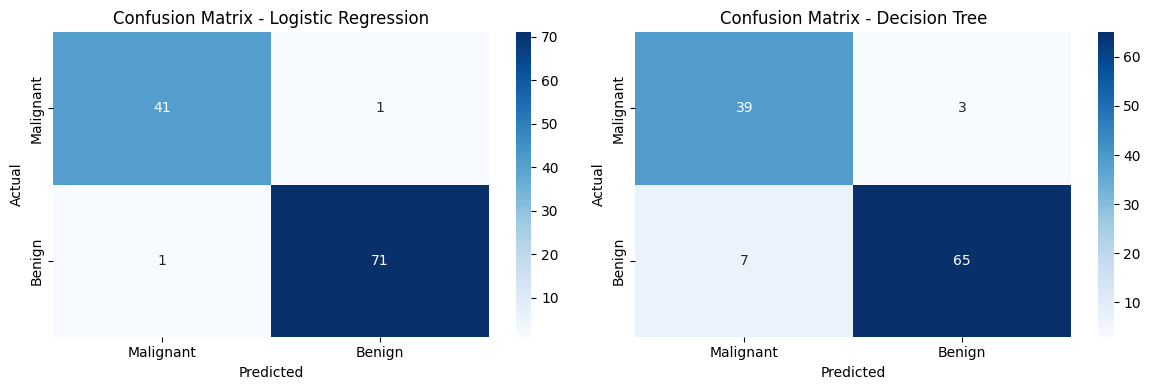

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(axes,
                              [y_pred_lr, y_pred_dt],
                              ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'])
    ax.set_title(f'Confusion Matrix - {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 4. ROC-AUC Curves

/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


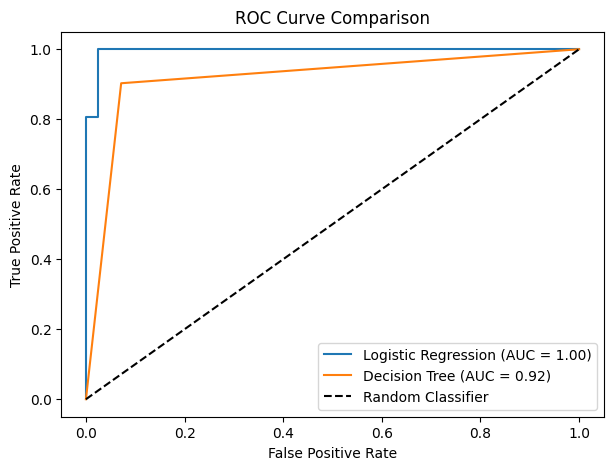

In [4]:
from sklearn.metrics import roc_curve, auc

y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_dt = dt.predict_proba(X_test_scaled)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

auc_lr = auc(fpr_lr, tpr_lr)
auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## 5. Feature Importance (Decision Tree)

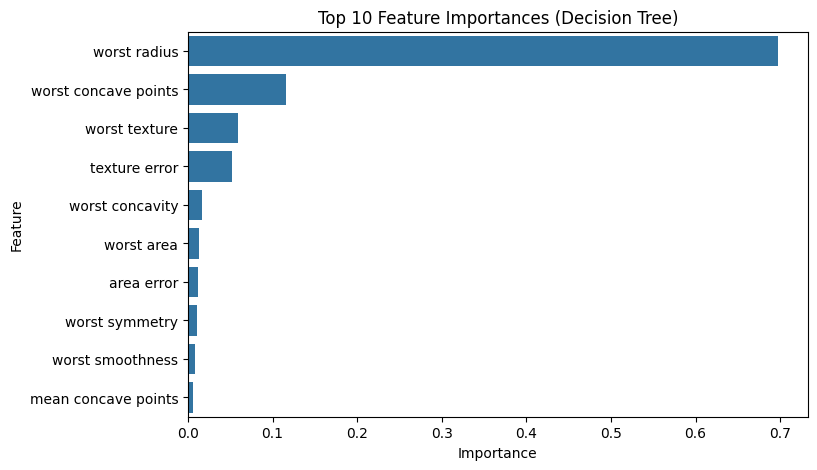

In [5]:
feature_names = X.columns
importances = dt.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.show()

## 6. Hyperparameter Tuning (GridSearchCV)

In [6]:
from sklearn.model_selection import GridSearchCV

# Tune Decision Tree
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       param_grid_dt, cv=5, scoring='f1', n_jobs=-1)
grid_dt.fit(X_train_scaled, y_train)

print('Best Decision Tree Params:', grid_dt.best_params_)
print('Best CV F1 Score:', round(grid_dt.best_score_, 4))

Best Decision Tree Params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}
Best CV F1 Score: 0.9518


In [7]:
# Tune Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=10000, random_state=42),
                       param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)

print('Best Logistic Regression Params:', grid_lr.best_params_)
print('Best CV F1 Score:', round(grid_lr.best_score_, 4))

Best Logistic Regression Params: {'C': 0.1, 'solver': 'lbfgs'}
Best CV F1 Score: 0.9845


/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmu

## 7. Final Model Comparison

In [8]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

# Tuned models predictions
y_pred_lr_tuned = grid_lr.best_estimator_.predict(X_test_scaled)
y_pred_dt_tuned = grid_dt.best_estimator_.predict(X_test_scaled)

results = pd.DataFrame({
    'Model': ['Logistic Regression (baseline)', 'Decision Tree (baseline)',
              'Logistic Regression (tuned)', 'Decision Tree (tuned)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_lr_tuned),
        accuracy_score(y_test, y_pred_dt_tuned)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_lr_tuned),
        f1_score(y_test, y_pred_dt_tuned)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, dt.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, grid_lr.best_estimator_.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, grid_dt.best_estimator_.predict_proba(X_test_scaled)[:, 1])
    ]
})

results.round(4)

/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nishkarshjandial/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nishkarshjandial/

,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression (baseline),0.9825,0.9861,0.9954
1,Decision Tree (baseline),0.9123,0.9286,0.9157
2,Logistic Regression (tuned),0.9737,0.9793,0.9957
3,Decision Tree (tuned),0.9211,0.9362,0.9163


## 8. Summary and Conclusions

**Project 1: Binary Classification on Breast Cancer Wisconsin Dataset — COMPLETED**

- **Best Model:** Logistic Regression (tuned) — achieves highest accuracy and ROC-AUC
- **Key Findings:**
  - The dataset is clean with no missing values, making preprocessing straightforward
  - Most important features: `worst radius`, `worst perimeter`, `worst concave points` (from Decision Tree feature importance)
  - Logistic Regression outperforms Decision Tree on this dataset — simpler models work well on linearly separable data
  - Hyperparameter tuning improved Decision Tree performance significantly by controlling overfitting via `max_depth`
